[NumPy](http://www.numpy.org) je základní Python knihovna pro práci s numerickými daty, konkrétně s 1- až n-rozměrnými maticemi. Implementace (pro CPython) je z velké části napsána v C a Fortranu a používá BLAS knihovny. Numpy tak umožňuje pracovat s numerickými daty ve stylu Python kontejnerů (existují samozřejmě rozdíly) a zároveň zachovat rychlost kompilovaných jazyků.

V této lekci se dozvíte a naučíte:
- Proč potřebujeme `numpy` pro efektivní práci s numerickými daty.
- Vytvářet `numpy` pole.
- Vektorové a maticové operace s `numpy.array`.
- Užitečné a pokročilejší `numpy` "triky".
<!-- TEASER_END -->

Tento notebook byl z části převzat a přeložen z J.R. Johansson: [Lectures on scientific computing with Python](http://github.com/jrjohansson/scientific-python-lectures) - díky.

## Importujeme numpy

Chceme-li použít `numpy`, je samozřejmě nutné modul importovat. Obvykle se použivá zkratka `np`: 


In [1]:
import numpy as np

## IPython pylab

Můžeme také použít prostředí `pylab`, které oba importy provede. Navíc importuje také grafickou knihovnu `matplotlib`, kterou blíže představíme později.

In [2]:
%pylab inline --no-import-all

Populating the interactive namespace from numpy and matplotlib


## Vytváříme `numpy` pole (`array`)
Existuje několik základních způsobů, jak vytvořit nové numpy pole.

* Z nějakého kontejneru typu seznam (`list`) nebo `tuple`.
* Pomocí funkce numpy, která generuje `array`, např. `zeros` nebo `arange`.
* Načtením ze souboru.

### Ze seznamu
Na seznam použijeme funkci `array`.

In [3]:
vector = np.array([1, 2, 3, 4])
vector

array([1, 2, 3, 4])

Vícerozměrné pole (matice) se vytvoří z vnořeného seznamu.

In [4]:
matrix = np.array([[1, 2], [3, 4]])
matrix

array([[1, 2],
       [3, 4]])

`v` and `M` jsou oboje typu `ndarray`.

In [5]:
type(vector), type(matrix)

(numpy.ndarray, numpy.ndarray)

Rozdíl mezi nimi je jejich rozměr, který dostaneme pomocí `shape` property (property proto, že shape lze i měnit).

In [6]:
vector.shape

(4,)

In [7]:
matrix.shape

(2, 2)

Počet prvků získáme pomocí `size`.

In [8]:
matrix.size

4

In [9]:
vector.size

4

Počet dimenzí je v `ndim`.

In [10]:
matrix.ndim

2

## Proč NumPy?

Zatím vypadá `numpy.ndarray` hodně podobně jako (vnořený) seznam. Proč jednoduše tedy jednoduše nepoužívat seznam místo vytváření nového typu?
Existuje několik velmi dobrých důvodů:

* Python seznamy jsou příliš obecné. Mohou obsahovat jakýkoliv druh objektu. Jsou dynamicky typované. Nepodporují matematické funkce, jako maticové násobení. Implementating takové funkce pro seznamy by nebylo příliš efektivní.
* NumPy pole jsou staticky typovaná a homogenní. Typ prvků je určen při vytvoření pole.
* NumPy pole jsou efektivně uložena v paměti.
* Díky těmto vlastnostem lze implementovat matematické operace, jako je násobení nebo sčítání, v rychlém, kompilovaném jazyce (C/Fortran).
Použití dtype (datový typ) vlastnost ndarray, můžeme vidět, jaký typ dat v poli má:

`dtype` property vrátí typ prvků v numpy poli.

In [11]:
matrix.dtype

dtype('int64')

Jiný typ do pole uložit nelze:

In [12]:
matrix[0,0] = "hello"

ValueError: invalid literal for int() with base 10: 'hello'

Typ prvků můžeme deklarovat explicitně při vytváření pole.

In [13]:
matrix = np.array([[1, 2], [3, 4]], dtype=complex)
matrix

array([[1.+0.j, 2.+0.j],
       [3.+0.j, 4.+0.j]])

Běžné (vestavěné) typy pro `dtype` jsou: `int`, `float`, `complex`, `bool`, `object`, atd.

Můžeme také definovat velikost pomocí `numpy` typů `int64`, `int16`, `float128`, `complex128`, aj.

## Pomocné generátory polí
Zejména velká pole by bylo nepraktické inicializovat pomocí seznamů. Naštěstí v numpy existují [funkce](http://docs.scipy.org/doc/numpy/reference/routines.array-creation.html), které generují typická pole.

**`arange`** vygeneruje posloupnost, syntaxe je stejná jako `range`

In [14]:
np.arange(0, 10, 1)  # argumenty: start, stop, step

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [15]:
np.arange(-1, 0, 0.1)

array([-1. , -0.9, -0.8, -0.7, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1])

**`linspace`** a **`logspace`** vytváří posloupnosti s daným počtem prvků.

In [16]:
# první a poslední prvek jsou obsaženy ve výsledku
np.linspace(0, 10, 9)

array([ 0.  ,  1.25,  2.5 ,  3.75,  5.  ,  6.25,  7.5 ,  8.75, 10.  ])

In [17]:
np.logspace(0, 10, 9, base=10)

array([1.00000000e+00, 1.77827941e+01, 3.16227766e+02, 5.62341325e+03,
       1.00000000e+05, 1.77827941e+06, 3.16227766e+07, 5.62341325e+08,
       1.00000000e+10])

**`ones`** a **`zeros`** vytvoří pole ze samých nul nebo jedniček.

In [18]:
np.ones(3)

array([1., 1., 1.])

In [19]:
# pokud chceme 2 a více rozměrů, musíme zadat rozměr jako tuple
np.zeros((2, 3))

array([[0., 0., 0.],
       [0., 0., 0.]])

**`mgrid`** tvoří pravidelnou mříž.

In [20]:
# všimněte si syntaxe s hranatými závorkami, mgrid se nevolá jako funkce
x, y = np.mgrid[0:3, 0:3]
print(x)
print(y)

[[0 0 0]
 [1 1 1]
 [2 2 2]]
[[0 1 2]
 [0 1 2]
 [0 1 2]]


Náhodná data vytvoří funkce **`rand`** a další z modulu **`random`**.

In [21]:
# několik náhodných čísel [0, 1] s rovnoměrným rozdělením
np.random.rand(4)

array([0.15529705, 0.0499254 , 0.01397413, 0.58220913])

In [22]:
# matice s náhodnými čísly z normálním rozdělením
np.random.randn(4, 4)

array([[-0.76158553, -0.55710863, -0.17808108, -0.41961596],
       [ 0.10836793, -0.7971841 ,  0.54279557,  0.10235548],
       [-0.99893177, -0.394416  , -0.67345019,  2.24196612],
       [-1.03603002,  1.31429548, -0.47982934, -0.45565889]])

**`diag`** vytvoří diagonální matici, případně vrátí diagonálu matice.

In [23]:
# diagonální matice
np.diag([1, 2, 3])

array([[1, 0, 0],
       [0, 2, 0],
       [0, 0, 3]])

In [24]:
# vrátí diagonálu jako vektor
np.diag(np.diag([1, 2, 3]))

array([1, 2, 3])

### Cvičení

1. Vytvořte náhodné pole 3x3x3
2. Vytvořte matici 5x5 kde jediné nenulová prvky jsou [1, 2, 3, 4] pod diagonálou (nápověda - podívejte se na nápovědu funkce `diag`).
```
0 0 0 0 0
1 0 0 0 0
0 2 0 0 0
0 0 3 0 0 
0 0 0 4 0
```

## Práce se soubory

### ASCII soubory
S textovými (ASCII) soubory obsahující data se setkáváme stále často, přestože to z mnoha důvodů není ideální formát. Na čtení ASCII (spadá sem i CSV) máme v Numpy `genfromtxt` a `loadtxt`. V [dokumentaci](http://docs.scipy.org/doc/numpy/reference/routines.io.html) se dozvíte, jak přesně fungují a jaké mají argumenty.

Pomocí `%%file` vytvoříme soubor `ascii_data_1.txt`

In [25]:
%%file ascii_data_1.txt
 1    -6.1    -6.1    -6.1 1
 2   -15.4   -15.4   -15.4 1
 3   -15.0   -15.0   -15.0 1
 4   -19.3   -19.3   -19.3 1
 5   -16.8   -16.8   -16.8 1
 6   -11.4   -11.4   -11.4 1
 7    -7.6    -7.6    -7.6 1
 8    -7.1    -7.1    -7.1 1
 9   -10.1   -10.1   -10.1 1
10    -9.5    -9.5    -9.5 1

Overwriting ascii_data_1.txt


Nyní se pokusíme soubor načíst pomocí `genfromtxt`.

In [26]:
data = np.genfromtxt('ascii_data_1.txt')
print(data)

[[  1.   -6.1  -6.1  -6.1   1. ]
 [  2.  -15.4 -15.4 -15.4   1. ]
 [  3.  -15.  -15.  -15.    1. ]
 [  4.  -19.3 -19.3 -19.3   1. ]
 [  5.  -16.8 -16.8 -16.8   1. ]
 [  6.  -11.4 -11.4 -11.4   1. ]
 [  7.   -7.6  -7.6  -7.6   1. ]
 [  8.   -7.1  -7.1  -7.1   1. ]
 [  9.  -10.1 -10.1 -10.1   1. ]
 [ 10.   -9.5  -9.5  -9.5   1. ]]


`loadtxt` by mělo fungovat také:

In [27]:
data2 = np.loadtxt('ascii_data_1.txt')
print(data2)

[[  1.   -6.1  -6.1  -6.1   1. ]
 [  2.  -15.4 -15.4 -15.4   1. ]
 [  3.  -15.  -15.  -15.    1. ]
 [  4.  -19.3 -19.3 -19.3   1. ]
 [  5.  -16.8 -16.8 -16.8   1. ]
 [  6.  -11.4 -11.4 -11.4   1. ]
 [  7.   -7.6  -7.6  -7.6   1. ]
 [  8.   -7.1  -7.1  -7.1   1. ]
 [  9.  -10.1 -10.1 -10.1   1. ]
 [ 10.   -9.5  -9.5  -9.5   1. ]]


`savetxt` můžeme použít na uložení.

In [28]:
np.savetxt("ascii_data_1_new.txt", data, fmt="%6g")

Pomocí `%less` můžeme soubor vypsat:

In [29]:
%less ascii_data_1_new.txt

     1   -6.1   -6.1   -6.1      1
     2  -15.4  -15.4  -15.4      1
     3    -15    -15    -15      1
     4  -19.3  -19.3  -19.3      1
     5  -16.8  -16.8  -16.8      1
     6  -11.4  -11.4  -11.4      1
     7   -7.6   -7.6   -7.6      1
     8   -7.1   -7.1   -7.1      1
     9  -10.1  -10.1  -10.1      1
    10   -9.5   -9.5   -9.5      1


### Npy formát
Pomocí `save` a `load` můžete jednoduše ukládat a nahrávat Numpy objekty.

In [30]:
np.save("ascii_data_1_new.npy", data)

In [31]:
data2 = np.load("ascii_data_1_new.npy")

Zkusíme, jestli jsou data stejná:

In [32]:
assert np.all(data == data2)

Všimli jste si použití `np.all` místo `all` nebo pouze `assert data == data2`? Tak jako tak, zkuste si co se stane pokud nepoužijeme `np.all`.

## Práce s NumPy poli

### Indexování a řezání

In [33]:
vector = np.linspace(0, 3, 7)
vector

array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. ])

Numpy pole můžeme indexovat podobně jako list.

První prvek vektoru:

In [34]:
vector[0]

0.0

In [35]:
matrix = np.array([[1, 2], [3, 4]], dtype=int)
matrix

array([[1, 2],
       [3, 4]])

Pro matice můžeme použít rozšířeného indexování - více argumentů pro řez:

In [36]:
matrix[1, 1]

4

Pokud jeden index vynecháme, vrátí numpy N-1 rozměrný řez.

In [37]:
matrix[1]

array([3, 4])

Toho samého docílíme pomocí :.

In [40]:
matrix[1, :]

array([3, 4])

První sloupec:

In [43]:
matrix[:, 1]

array([2, 4])

Můžeme také (na rozdíl od `list`u) přiřazovat honoty do indexovaných polí.

In [44]:
matrix[0, 0] = -10
print(matrix)

[[-10   2]
 [  3   4]]


Funguje to i pro více prvků:

In [45]:
matrix[1, :] = 0
print(matrix)

[[-10   2]
 [  0   0]]


Řezy mají stejnou syntaxi jako pro seznamy (řezy jsou ostatně koncept Pythonu jako takového). Pro připomenutí, tato syntaxe je `[dolní_mez:horní_mez:krok]`.

In [54]:
my_array = np.arange(1, 10)
my_array

array([1, 2, 3, 4, 5, 6, 7, 8, 9])

Jednoduchý řez s krokem 1:

In [55]:
my_array[1:3]

array([2, 3])

Řez s krokem 2

In [56]:
my_array[:-1:2]

array([1, 3, 5, 7])

**Řezy jsou mutable**: pokud do nich něco přiřadíme, projeví se to na původním objektu.

In [58]:
my_array[1:3] = [-2, -3]
my_array

array([ 1, -2, -3,  4,  5,  6,  7,  8,  9])

Řezy fungují i pro vícerozměrné matice.

In [59]:
my_array = np.array([[n + m * 10 for n in range(5)] for m in range(5)])
my_array

array([[ 0,  1,  2,  3,  4],
       [10, 11, 12, 13, 14],
       [20, 21, 22, 23, 24],
       [30, 31, 32, 33, 34],
       [40, 41, 42, 43, 44]])

Část původní matice

In [63]:
my_array[3:, 1:-1]

array([[31, 32, 33],
       [41, 42, 43]])

Řez s krokem 2

In [65]:
my_array[::2, ::2]

array([[ 0,  2,  4],
       [20, 22, 24],
       [40, 42, 44]])

### Jetě elegantnější vyřezávání
Pro řezy můžeme použít nejen čísla, ale také přímo pole. Např. pro výběr některých řádků

In [66]:
row_indices = [1, 2]
my_array[row_indices]

array([[10, 11, 12, 13, 14],
       [20, 21, 22, 23, 24]])

Můžeme indexovat i dvěmi poli:

In [69]:
my_array[[1, 2], [1, -1]]

array([11, 24])

Můžeme také použít **maskování**. Např. vytvoříme masku dělitelnosti 3mi.

In [70]:
mask3 = my_array % 3 == 0
print(mask3)

[[ True False False  True False]
 [False False  True False False]
 [False  True False False  True]
 [ True False False  True False]
 [False False  True False False]]


Tuto masku pak můžeme použít pro vytvoření řezu.

In [71]:
my_array[mask3]

array([ 0,  3, 12, 21, 24, 30, 33, 42])

### Cvičení

1. Vyvořte co nejelegantnějším způsobem 8x8 matici, která vypadá jako šachovnice.
```
0 1 0 1 0 1 0 1
1 0 1 0 1 0 1 0
0 1 0 1 0 1 0 1
1 0 1 0 1 0 1 0
0 1 0 1 0 1 0 1
1 0 1 0 1 0 1 0
0 1 0 1 0 1 0 1
1 0 1 0 1 0 1 0
```

## Lineární algebra
Numpy dokáže velice obratně a efektivně pracovat s vektory, maticemi a n-dimenzionálními poli obecně. Toho je potřeba využívat a kdekoli to je možné použít *vektorizovaný kód*, tj. co nejvíce formulovat úlohy pomocí vektorových a maticových operací, jako jsou např. násobení matic.

### Operace se skaláry
Jak bychom asi očekávali, skalárem můžeme násobit, dělit, můžeme ho přičítat nebo odečítat.

In [72]:
v1 = np.arange(0, 5)

In [73]:
v1 * 2

array([0, 2, 4, 6, 8])

In [74]:
v1 + 2

array([2, 3, 4, 5, 6])

In [75]:
np.ones((3, 3)) / 4

array([[0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25]])

## Maticové operace po prvcích
Operace jako násobení, sčítání atd. jsou v numpy stardadně *po prvcích*, není to tedy klasická maticová (vektorová) algebra.

In [86]:
m1 = np.array([[n + m * 10 for n in range(5)] for m in range(5)])
m1

array([[ 0,  1,  2,  3,  4],
       [10, 11, 12, 13, 14],
       [20, 21, 22, 23, 24],
       [30, 31, 32, 33, 34],
       [40, 41, 42, 43, 44]])

In [81]:
m1 * m1

array([[   0,    1,    4,    9,   16],
       [ 100,  121,  144,  169,  196],
       [ 400,  441,  484,  529,  576],
       [ 900,  961, 1024, 1089, 1156],
       [1600, 1681, 1764, 1849, 1936]])

In [82]:
v1 * v1

array([ 0,  1,  4,  9, 16])

Pokud se dají pole rozšířit na společný rozměr, numpy to za nás udělá.

In [83]:
v1.shape, m1.shape

((5,), (5, 5))

Výsledek bude mít rozměr `m1.shape`

In [87]:
m1 * v1

array([[  0,   1,   4,   9,  16],
       [  0,  11,  24,  39,  56],
       [  0,  21,  44,  69,  96],
       [  0,  31,  64,  99, 136],
       [  0,  41,  84, 129, 176]])

## Maticová algebra
Klasickou maticovou algebru zajišťuje pro pole typu `ndarray` funkce `dot`.

In [88]:
# maticové násobení dvou matic
np.dot(m1, m1)

array([[ 300,  310,  320,  330,  340],
       [1300, 1360, 1420, 1480, 1540],
       [2300, 2410, 2520, 2630, 2740],
       [3300, 3460, 3620, 3780, 3940],
       [4300, 4510, 4720, 4930, 5140]])

In [89]:
# maticové násobení vektoru a matice
np.dot(m1, v1)

array([ 30, 130, 230, 330, 430])

In [90]:
# skalární součin
np.dot(v1, v1)

30

Případně lze použít operátor `@` ([PEP-465](https://www.python.org/dev/peps/pep-0465/)):

In [91]:
v1 @ v1

30

### Existuje ještě třída `matrix` se standardně násobí maticově
Pro třídu `matrix` jsou operátory `+, -, *` maticové.

In [92]:
m1_matrix = np.matrix(m1)
# sloupcový vektor vyrobíme transpozicí
v1_matrix = np.matrix(v1).T
v1_matrix.shape

(5, 1)

In [93]:
# tohle je maticové násobení
m1_matrix * m1_matrix

matrix([[ 300,  310,  320,  330,  340],
        [1300, 1360, 1420, 1480, 1540],
        [2300, 2410, 2520, 2630, 2740],
        [3300, 3460, 3620, 3780, 3940],
        [4300, 4510, 4720, 4930, 5140]])

In [94]:
# matice × vektor
m1_matrix * v1_matrix

matrix([[ 30],
        [130],
        [230],
        [330],
        [430]])

In [95]:
# skalární součin
v1_matrix.T * v1_matrix

matrix([[30]])

Další informace viz. [dokumentace](http://docs.scipy.org/doc/numpy/reference/routines.linalg.html#matrix-and-vector-products).

## Transformace
Už jsme viděli `.T` pro transponování. Existuje také funkce `transpose`. Dále existuje `conjugate` pro sdružení nebo `.H` pro Hermitovské sdružení,.

In [96]:
C = np.matrix([[1j, 2j], [3j, 4j]])
C

matrix([[0.+1.j, 0.+2.j],
        [0.+3.j, 0.+4.j]])

In [97]:
np.conjugate(C)      # nebo C.conjugate()

matrix([[0.-1.j, 0.-2.j],
        [0.-3.j, 0.-4.j]])

In [98]:
C.H

matrix([[0.-1.j, 0.-3.j],
        [0.-2.j, 0.-4.j]])

Reálnou a imaginární část dostaneme pomocí `real` a `imag` nebo `.real` a `.imag` properties:

In [99]:
np.real(C)

matrix([[0., 0.],
        [0., 0.]])

In [100]:
C.imag

matrix([[1., 2.],
        [3., 4.]])

Komplexní číslo rozložíme na absolutní hodnotu a úhel pomocí `abs` a `angle`.

In [101]:
np.angle(C+1)

array([[0.78539816, 1.10714872],
       [1.24904577, 1.32581766]])

In [102]:
np.abs(C+1)

matrix([[1.41421356, 2.23606798],
        [3.16227766, 4.12310563]])

## Základní funkce lineární algebry

V Numpy existuje modul `linalg`. Pokročilejší lineární algebru je ale třeba hledat jinde, např. ve SciPy. 

Invertovat matici můžeme pomocí `linalg.inv` nebo `.I.

In [103]:
np.linalg.inv(C)

matrix([[0.+2.j , 0.-1.j ],
        [0.-1.5j, 0.+0.5j]])

In [104]:
C.I * C

matrix([[1.00000000e+00+0.j, 0.00000000e+00+0.j],
        [2.22044605e-16+0.j, 1.00000000e+00+0.j]])

`linalg.det` vypočítá determinant.

In [105]:
np.linalg.det(C)

(2.0000000000000004+0j)

### Cvičení

1. Ověřte empiricky na náhodné matici, že platí $(AB)^T = B^T A^T$


## Zpracování dat

Numpy je vhodné pro práci se soubory dat, pro které poskytuje řadu funkcí, např. statistických.

Zkusme nějakou statistiku na souboru teplot ve Stockholmu. Data si můžete stáhnout z http://www.pythonic.eu/fjfi/data/stockholm_td_adj.dat.

In [107]:
data = np.genfromtxt('data/stockholm_td_adj.dat')    # Lze přímo vložit i URL
np.shape(data)

(77431, 7)

#### mean (aritmetický průměr)

In [109]:
# the temperature data is in column 3
print("The daily mean temperature in Stockholm over the last 200 year so has been about {:.1f} °C.".format(np.mean(data[:, 3])))

The daily mean temperature in Stockholm over the last 200 year so has been about 6.2 °C.


#### směrodatná odchylka a variance

In [110]:
np.std(data[:, 3]), np.var(data[:, 3])

(8.282271621340573, 68.59602320966341)

#### min a max

In [111]:
# nejnižší denní teplota
data[:, 3].min()

-25.8

In [112]:
# nejvyšší denní teplota
data[:, 3].max()

28.3

#### sum, prod, trace

In [113]:
d = np.arange(1, 11)
d

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [114]:
# sečíst všechny prvky
np.sum(d)

55

In [115]:
# násobek všech prvků
np.prod(d)

3628800

In [116]:
# kumulativní součet
np.cumsum(d)

array([ 1,  3,  6, 10, 15, 21, 28, 36, 45, 55])

In [117]:
# kumulativní násobení
np.cumprod(d)

array([      1,       2,       6,      24,     120,     720,    5040,
         40320,  362880, 3628800])

In [120]:
# stejné jako diag(m1).sum()
np.trace(m1)

110

## Výpočty s částmi polí

Výpočty můžeme také provádět na podmnožinách dat pomocí indexování (jednoduchého či pokročilého) a dalších metod ukázaných níže.

Vraťme se k údajům o teplotě.

In [121]:
data[1]

array([ 1.80e+03,  1.00e+00,  2.00e+00, -1.54e+01, -1.54e+01, -1.54e+01,
        1.00e+00])

Format je: rok, měsíc, den, průměrná teplota, nejnižší teplota, nejvyšší teplota, poloha.

Pokud chceme spočítat průměrnou teplotu v konkrétním měsíci, např únoru, můžeme použít *maskování*.


In [123]:
np.unique(data[:, 1]) # měsíce mají hodnoty 1 - 12

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.])

In [124]:
# vytvoříme masku
mask_feb = data[:, 1] == 2

In [125]:
# masku použijeme jako index
print(u"Průměrná únorová teplota je {:.1f} °C".format(np.mean(data[mask_feb, 3])))

Průměrná únorová teplota je -3.2 °C


Získání průměrných teplot pro všechny měsíce je také jednoduché.


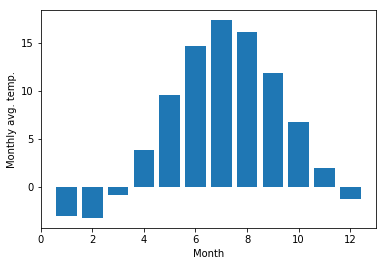

In [126]:
months = np.arange(1,13)
monthly_mean = [np.mean(data[data[:, 1] == month, 3]) for month in months]

# teď používáme matplotlib, se kterým se naučíme příště :)
fig, ax = plt.subplots()
ax.bar(months, monthly_mean)
ax.set_xlabel("Month")
ax.set_ylabel("Monthly avg. temp.");

### Výpočty s vícerozměrnými daty

Pokud je funkce jako `min`, `max` apod. použita na vícerozměrné pole, je někdy účelem ji aplikovat na celé pole, jindy zase po řádcích nebo sloupcích. K tomuto účelu slouží argument `axis`.

In [129]:
m = np.random.rand(3, 3)
m

array([[0.303585  , 0.05202307, 0.06276996],
       [0.20181146, 0.86021882, 0.9895665 ],
       [0.54994216, 0.67268655, 0.95412183]])

In [130]:
# globální max
m.max()

0.9895664980909618

In [131]:
# max pro každý sloupec
m.max(axis=0)

array([0.54994216, 0.86021882, 0.9895665 ])

In [132]:
# max pro každý řádek
m.max(axis=1)

array([0.303585  , 0.9895665 , 0.95412183])

Argument `axis` používá mnoho dalších funkcí z numpy.

## Změny rozměrů a spojování polí

Rozměr Numpy polí může být měněn bez kopírování samotných dat, což výrazně tyto operace zrychluje.

In [134]:
m1

array([[ 0,  1,  2,  3,  4],
       [10, 11, 12, 13, 14],
       [20, 21, 22, 23, 24],
       [30, 31, 32, 33, 34],
       [40, 41, 42, 43, 44]])

In [136]:
n, m = m1.shape

Např. takto můžeme vytvořit jednorozměrné pole

In [138]:
m1.reshape((1, n*m))

array([[ 0,  1,  2,  3,  4, 10, 11, 12, 13, 14, 20, 21, 22, 23, 24, 30,
        31, 32, 33, 34, 40, 41, 42, 43, 44]])

Nebo použít -1 pro automatické dopočítání

In [141]:
m1.reshape((1, -1))

array([[ 0,  1,  2,  3,  4, 10, 11, 12, 13, 14, 20, 21, 22, 23, 24, 30,
        31, 32, 33, 34, 40, 41, 42, 43, 44]])

Ovšem pozor: jelikož data jsou společná, změna v novém poli se projeví i v původním! Numpy to nazývá *views* - pohledy.

In [142]:
m2 = m1.reshape((1, -1))

In [143]:
m2[0, 0:5] = 5 # modify the array
m2

array([[ 5,  5,  5,  5,  5, 10, 11, 12, 13, 14, 20, 21, 22, 23, 24, 30,
        31, 32, 33, 34, 40, 41, 42, 43, 44]])

Změny se projeví i v původním `m1`

In [144]:
m1

array([[ 5,  5,  5,  5,  5],
       [10, 11, 12, 13, 14],
       [20, 21, 22, 23, 24],
       [30, 31, 32, 33, 34],
       [40, 41, 42, 43, 44]])

Funkce `flatten` vytvoří jednorozměrné pole (vektor), data jsou v tomto případě kopírována.

In [145]:
m1.flatten()

array([ 5,  5,  5,  5,  5, 10, 11, 12, 13, 14, 20, 21, 22, 23, 24, 30, 31,
       32, 33, 34, 40, 41, 42, 43, 44])

### Přidávání dimenzí: `newaxis`

Pomocí `newaxis` můžeme jednoduše pomocí řezů přidávat dimenze. Např. převod 1d vektoru na sloupcovou nebo řádkovou matici.

In [146]:
v = np.array([1, 2, 3])
v.shape

(3,)

In [147]:
# vytvoříme sloupec
vc = v[:, np.newaxis]
vc

array([[1],
       [2],
       [3]])

In [148]:
vc.shape

(3, 1)

In [149]:
# řádek
v[np.newaxis, :].shape

(1, 3)

### Spojování a opakování

Na spojování a opakování máme funkce `repeat`, `tile`, `vstack`, `hstack` a `concatenate`.

In [150]:
a = np.array([[1, 2], [3, 4]])
a

array([[1, 2],
       [3, 4]])

In [151]:
# opakování po prvcích
np.repeat(a, 3)

array([1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4])

In [152]:
# skládání celých polí 
np.tile(a, (3, 2))

array([[1, 2, 1, 2],
       [3, 4, 3, 4],
       [1, 2, 1, 2],
       [3, 4, 3, 4],
       [1, 2, 1, 2],
       [3, 4, 3, 4]])

`concatenate` spojí dvě pole

In [153]:
b = np.array([[5, 6]])

In [154]:
np.concatenate((a, b), axis=0)

array([[1, 2],
       [3, 4],
       [5, 6]])

In [155]:
# musíme použít b.T
np.concatenate((a, b.T), axis=1)

array([[1, 2, 5],
       [3, 4, 6]])

`hstack` a `vstack` skládá pole horizontáleně nebo vertikálně

In [156]:
np.vstack((a, b))

array([[1, 2],
       [3, 4],
       [5, 6]])

In [157]:
np.hstack((a, b.T))

array([[1, 2, 5],
       [3, 4, 6]])

### Cvičení
1. Pro náhodné 1D vektory $u, v$ vypočítejte dyadický součin $uv$ ($uv_{ij} = u_iv_j$) pomocí `newaxis`.
2. Vytvořte šachovnicovou matici pomocí `tile`.

## Kopírování dat

Python obecně přiřazuje proměnné pomocí referencí. Numpy objekty nejsou výjimkou.

In [158]:
A = np.array([[1, 2], [3, 4]])
A

array([[1, 2],
       [3, 4]])

In [159]:
# B je teď identický objekt s A
B = A 

In [160]:
# změna v B se projeví v A
B[0, 0] = 10
A

array([[10,  2],
       [ 3,  4]])

Pokud chceme data zkopírovat, tj. pokud bychom chtěli aby `A` bylo nezávislé na `B`, můžeme použít metodu nebo funci `copy`.

In [162]:
B = A.copy()
# nebo B = np.copy(A)

In [163]:
# změny v B už se neprojeví v A
B[0, 0] = -5
A

array([[10,  2],
       [ 3,  4]])

## Iterace

Obecně se iteraci vyhýbáme a přednost dáváme vektorovým operacím (viz níže). Někdy je ale iterace nevyhnutelná.

In [165]:
v = np.array([1, 2, 3, 4])

for element in v:
    print(element)

1
2
3
4


Iteruje se přes první index (po řádcích).

In [166]:
M = np.array([[1, 2], [3, 4]])

for row in M:
    print("row: {}".format(row))


row: [1 2]
row: [3 4]


Pokud potřebujeme také indexy, použijeme `enumerate`. (Vzpomínáte?)

In [167]:
for row_idx, row in enumerate(M):
    print("row_idx", row_idx, "row", row)
    
    for col_idx, element in enumerate(row):
        print("col_idx", col_idx, "element", element)
       
        # update the matrix M: square each element
        M[row_idx, col_idx] = element ** 2

row_idx 0 row [1 2]
col_idx 0 element 1
col_idx 1 element 2
row_idx 1 row [3 4]
col_idx 0 element 3
col_idx 1 element 4


In [168]:
# each element in M is now squared
M

array([[ 1,  4],
       [ 9, 16]])

## Vektorové funkce

Jak jsme již říkali, vektorové (vektorizované) funkce jsou obecně daleko rychlejší než iterace. Numpy nám naštěstí cestu od skalární po vektorovou funkci usnadňuje.

In [178]:
def Theta(x):
    """
    Scalar implemenation of the Heaviside step function.
    """
    if x >= 0:
        return 1
    else:
        return 0

In [179]:
# toto bychom chtěli, ale asi to nebude fungovat
Theta(np.array([-3, -2, -1, 0, 1, 2, 3]))

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

Pro vektorizaci naší funkce nám Numpy nabízí `vectorize`.

In [180]:
Theta_vec = np.vectorize(Theta)

In [181]:
Theta_vec(np.array([-3, -2, -1, 0, 1, 2, 3]))

array([0, 0, 0, 1, 1, 1, 1])

To bylo celkem snadné ... Můžeme také (a pokud to jde tak bychom měli) přepsat naší funkci tak, aby fungovala jak pro skaláry tak pro pole.

In [182]:
def Theta_numpy(x):
    """
    Vector-aware implemenation of the Heaviside step function.
    """
    return 1 * (x >= 0)

In [183]:
Theta_numpy(np.array([-3, -2, -1, 0, 1, 2, 3]))

array([0, 0, 0, 1, 1, 1, 1])

In [184]:
# funguje i pro skalár
Theta_numpy(-1.2), Theta_numpy(2.6)

(0, 1)

## Používání polí v podmínkách
Pokud chceme testovat po prvcí, v podmínkách pak použijeme metody `all` nebo `any`.

In [185]:
M

array([[ 1,  4],
       [ 9, 16]])

In [186]:
# výsledkem M > 5 je pole boolovských hodnot
M > 5

array([[False, False],
       [ True,  True]])

In [187]:
if (M > 5).any():
    print("M obsahuje alespoň jeden prvek větší než 5")
else:
    print("M neobsahuje žádný prvek větší než 5")

M obsahuje alespoň jeden prvek větší než 5


In [188]:
if (M > 5).all():
    print("všechny prvky v M jsou větší než 5")
else:
    print("M obsahuje alespoň jeden prvek menší rovno 5")

M obsahuje alespoň jeden prvek menší rovno 5


## Změna typů
Numpy pole jsou *staticky typované*. Pro změnu typu můžeme použít metodu `astype` (případně `asarray`).

In [189]:
M.dtype

dtype('int64')

In [190]:
M2 = M.astype(float)
M2

array([[ 1.,  4.],
       [ 9., 16.]])

In [191]:
M2.dtype

dtype('float64')

In [192]:
M3 = M.astype(bool)
M3

array([[ True,  True],
       [ True,  True]])

## Další čtení

* http://numpy.scipy.org
* http://scipy.org/Tentative_NumPy_Tutorial
* https://jakevdp.github.io/PythonDataScienceHandbook/02.00-introduction-to-numpy.html
* http://scipy.org/NumPy_for_Matlab_Users - A Numpy guide for MATLAB users.
* http://www.labri.fr/perso/nrougier/teaching/numpy.100/index.html